In [1]:
import warnings
from pathlib import Path
from matplotlib import pyplot as plt
import prism
import pandas as pd
import xarray as xr
import numpy as np
import logging

from imagematerials.factory import ModelFactory, Sector
from imagematerials.model import (
    EndOfLife,
    GenericMaterials,
    GenericStocks,
    Maintenance,
    MaterialIntensities,
    SharesInflowStocks,
    RestOf
)
from imagematerials.preprocessing import get_preprocessing_data
from imagematerials.rest_of import rest_of_preprocessing
from imagematerials.util import reindex_material

In [6]:
# Define the complete timeline, including historic tail

YEAR_START  = 2000    # start year of the simulation period
YEAR_END    = 2060    # end year of the calculations
YEAR_OUT    = 2060    # year of output generation = last year of reporting
time_start = 2000
complete_timeline = prism.Timeline(time_start, YEAR_END, 1)
simulation_timeline = prism.Timeline(YEAR_START, YEAR_OUT, 1)


# Define the scenario list
scenario_list = {
                
                "base":("SSP2",["base"]),
                "narrow_product":("SSP2", ["base", "narrow_product"]),
                "narrow_activity":("SSP2_narrow", ["base", "narrow_activity"]),
                "narrow":("SSP2_narrow", ["base", "narrow_product", "narrow_activity"]),
                #  "slow":("SSP2_slow",["base", "slow"]),
                #  "close":("SSP2",["base", "close"]),
                #  "narrow_slow_close":("SSP2_narrow_slow_close", ["base", "narrow","slow","close"])
                }

# Define paths
scenario_base_path = Path("..", "data", "raw")
CP_scenario_path = scenario_base_path/ "IMAGE_CircoMod"
CE_scenario_path = scenario_base_path / 'circular_economy_scenarios'

# define materials list so that arrays have consistent order
# IF A NEW MATERIAL SHOULD BE ADDED HERE, add it also in imagematerials.eol.preprocessing
materials = [
    'aluminium', 'brick', 'cement', 'cobalt', 'concrete', 'copper', 'glass',        
    'lead', 'lithium', 'manganese', 'neodymium', 'nickel', 'plastics',
    'rubber', 'steel', 'tantalum', 'titanium', 'wood'
]

In [7]:
# Run simulations for all scenarios

all_output = {} # to store outputs for all scenarios

# add debugging statements
logging.basicConfig(
    level=logging.DEBUG,
    format='%(name)s - %(levelname)s - %(message)s',
    force=True  # Override any existing config
)

# Loop over scenarios
for scen_id, (climate_scen, circular_scen) in scenario_list.items():
    print(f"Running scenario: {climate_scen} from {CP_scenario_path}")
    print(f"Circular economy scenario: {circular_scen}")
    climate_policy_scenario_dir = CP_scenario_path / climate_scen           # path to climate policy scenario data (i.e., from IMAGE)
    circular_economy_scenario_dirs = {
        scenario: CE_scenario_path / scenario for scenario in circular_scen # path to circular economy scenario data
    }

# Get preprocessing data for all sectors and adjust material indices
    
    # BUILDINGS
    bld_sector = get_preprocessing_data("buildings", scenario_base_path, climate_policy_scenario_dir, circular_economy_scenario_dirs)

    #VEHICLES
    vhc_sector = get_preprocessing_data("vehicles", scenario_base_path, climate_policy_scenario_dir, circular_economy_scenario_dirs)

    # #ELECTRICITY
    elc_sector = get_preprocessing_data("electricity", scenario_base_path, climate_policy_scenario_dir, circular_economy_scenario_dirs, cache = False)
    elc_gen, elc_grid_lines, elc_grid_add, elc_stor_phs, elc_stor_other = (
    {sec.name: sec for sec in elc_sector}[k]
    for k in ["elc_gen", "elc_grid_lines", "elc_grid_add", "elc_stor_phs", "elc_stor_other"])
    
    # END OF LIFE
    eol_sector = get_preprocessing_data("eol", scenario_base_path, circular_economy_scenario_dirs)
    
    # #REST OF
    rest_sector = rest_of_preprocessing(scenario_base_path, climate_policy_scenario_dir,scenario = climate_scen) #TODO: add this to get_preprocessing_data function
    rest_sector = Sector(name='rest_of', data = rest_sector) # make it a Sector object!

    # Reindex materials in all sectors to ensure consistency
    for sec in [
    elc_gen,
    elc_grid_lines,
    elc_grid_add,
    elc_stor_phs,
    elc_stor_other,
    bld_sector,
    vhc_sector,
    eol_sector,
    rest_sector,
]:
        for key, val in sec.prep_data.items():
            sec.prep_data[key] = reindex_material(val, materials)

# Build and run the model
    factory = ModelFactory(
    [bld_sector, vhc_sector,
    *elc_sector,                # *: unpacks electricity sectors 
    eol_sector, 
    rest_sector,
    ],complete_timeline 
    ).add(GenericStocks, ["buildings", 
                          "vehicles", 
                          "elc_gen", "elc_grid_lines", "elc_grid_add", "elc_stor_phs"
                          ]
    ).add(SharesInflowStocks, ["elc_stor_other"]
    ).add(GenericMaterials,  "vehicles"
    ).add(MaterialIntensities, ["buildings",
                        "elc_gen", "elc_grid_lines","elc_grid_add","elc_stor_phs","elc_stor_other"
                        ]
    ).add(Maintenance, "vehicles"
    ).add(RestOf, "rest_of", input_sources={
       "gompertz_coefs": "rest_of",
        "gdp_per_capita": "rest_of",
        "population": "rest_of",
        "historic_diff_consumption_mean": "rest_of",
        "historic_diff_consumption_total": "rest_of"
}                  
    ).add(EndOfLife, "eol", input_sources={
    "outflow_by_cohort_materials": ["vehicles", "buildings",
                                    "elc_gen", "elc_grid_lines", "elc_grid_add", "elc_stor_phs"
                                    ],
    "inflow_materials":  ["vehicles", "buildings",
                          "elc_gen", "elc_grid_lines", "elc_grid_add", "elc_stor_phs"
                         ],
    "collection": "eol",
    "reuse": "eol",
    "recycling": "eol"}
)
    model = factory.finish() # create the model
    
    # Run the simulation (suppressing warnings)
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        model.simulate(simulation_timeline) 

     # save relevant outputs only to reduce memory usage
    all_output[scen_id] = {
        # MATERIAL inflows
        "inflow_materials": [model.vehicles["inflow_materials"], model.buildings["inflow_materials"], 
                             model.elc_gen["inflow_materials"], model.elc_grid_lines["inflow_materials"], model.elc_grid_add["inflow_materials"], model.elc_stor_phs["inflow_materials"], model.elc_stor_other["inflow_materials"], 
                             model.rest_of["inflow_materials"]],
        # MATERIAL stocks
        "stock_by_cohort_materials": [model.vehicles["stock_by_cohort_materials"], model.buildings["stock_by_cohort_materials"], 
                             model.elc_gen["stock_by_cohort_materials"], model.elc_grid_lines["stock_by_cohort_materials"], model.elc_grid_add["stock_by_cohort_materials"], model.elc_stor_phs["stock_by_cohort_materials"], model.elc_stor_other["stock_by_cohort_materials"]], 
        # MATERIAL outflows
        "outflow_by_cohort_materials": [model.vehicles["outflow_by_cohort_materials"], model.buildings["outflow_by_cohort_materials"],
            model.elc_gen["outflow_by_cohort_materials"], model.elc_grid_lines["outflow_by_cohort_materials"], model.elc_grid_add["outflow_by_cohort_materials"], model.elc_stor_phs["outflow_by_cohort_materials"], model.elc_stor_other["outflow_by_cohort_materials"]
            ],
        # PRODUCT inflows
        "inflow": [
            model.vehicles["inflow"], model.buildings["inflow"],
            model.elc_gen["inflow"], model.elc_grid_lines["inflow"], model.elc_grid_add["inflow"], model.elc_stor_phs["inflow"], model.elc_stor_other["inflow"]
            ],
        # PRODUCT stocks
        "stocks": [
            model.vehicles["stocks"],model.buildings["stocks"],
            model.elc_gen["stocks"], model.elc_grid_lines["stocks"], model.elc_grid_add["stocks"], model.elc_stor_phs["stocks"], model.elc_stor_other["stocks"]
            ],
        # PRODUCT outflows
        "outflow": [
            model.vehicles["stocks"], 
            model.buildings["stocks"],
            model.elc_gen["stocks"],model.elc_grid_lines["stocks"],model.elc_grid_add["stocks"],model.elc_stor_phs["stocks"],model.elc_stor_other["stocks"]
            ],
        # EoL materials
        "sum_outflow": model.eol["sum_outflow"],
        "reusable_materials": model.eol["reusable_materials"],
        "recyclable_materials": model.eol["recyclable_materials"]
    }
    print(f"Finished {scen_id}")

Running scenario: SSP2 from ..\data\raw\IMAGE_CircoMod
Circular economy scenario: ['base']


root - DEBUG - implemented 'base' for Commercial Buildings
root - DEBUG - implemented 'base' for Residential Buildings


Finished base
Running scenario: SSP2 from ..\data\raw\IMAGE_CircoMod
Circular economy scenario: ['base', 'narrow_product']


root - DEBUG - implemented 'base' for Commercial Buildings
root - DEBUG - implemented 'base' for Residential Buildings
root - DEBUG - implemented 'narrow_product' for Commercial Buildings (lightweighting)
root - DEBUG - implemented 'narrow_product' for Residential Buildings (lightweighting)
root - DEBUG - implemented 'narrow_product' for Vehicles (mileage/kilometrage increase)
root - DEBUG - implemented 'narrow_product' for Vehicles (lightweighting)


narrow|lightweighting applied to  GenerationMaterialIntensities
narrow|lightweighting applied to  GridMaterialIntensitiesAdditions
Finished narrow_product
Running scenario: SSP2_narrow from ..\data\raw\IMAGE_CircoMod
Circular economy scenario: ['base', 'narrow_activity']


root - DEBUG - implemented 'base' for Commercial Buildings
c:\Users\Zanon004\AppData\Local\miniforge3\envs\mat-env\Lib\site-packages\numpy\lib\_function_base_impl.py:2642: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  args = tuple(asanyarray(arg) for arg in args)
c:\Users\Zanon004\AppData\Local\miniforge3\envs\mat-env\Lib\site-packages\numpy\lib\_function_base_impl.py:2642: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  args = tuple(asanyarray(arg) for arg in args)
c:\Users\Zanon004\AppData\Local\miniforge3\envs\mat-env\Lib\site-packages\numpy\lib\_function_base_impl.py:2642: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  args = tuple(asanyarray(arg) for arg in args)
c:\Users\Zanon004\AppData\Local\miniforge3\envs\mat-env\Lib\site-packages\numpy\lib\_function_base_impl.py:2642: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarra

Finished narrow_activity
Running scenario: SSP2_narrow from ..\data\raw\IMAGE_CircoMod
Circular economy scenario: ['base', 'narrow_product', 'narrow_activity']


root - DEBUG - implemented 'base' for Commercial Buildings
c:\Users\Zanon004\AppData\Local\miniforge3\envs\mat-env\Lib\site-packages\numpy\lib\_function_base_impl.py:2642: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  args = tuple(asanyarray(arg) for arg in args)
c:\Users\Zanon004\AppData\Local\miniforge3\envs\mat-env\Lib\site-packages\numpy\lib\_function_base_impl.py:2642: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  args = tuple(asanyarray(arg) for arg in args)
c:\Users\Zanon004\AppData\Local\miniforge3\envs\mat-env\Lib\site-packages\numpy\lib\_function_base_impl.py:2642: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  args = tuple(asanyarray(arg) for arg in args)
c:\Users\Zanon004\AppData\Local\miniforge3\envs\mat-env\Lib\site-packages\numpy\lib\_function_base_impl.py:2642: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarra

narrow|lightweighting applied to  GenerationMaterialIntensities
narrow|lightweighting applied to  GridMaterialIntensitiesAdditions
Finished narrow


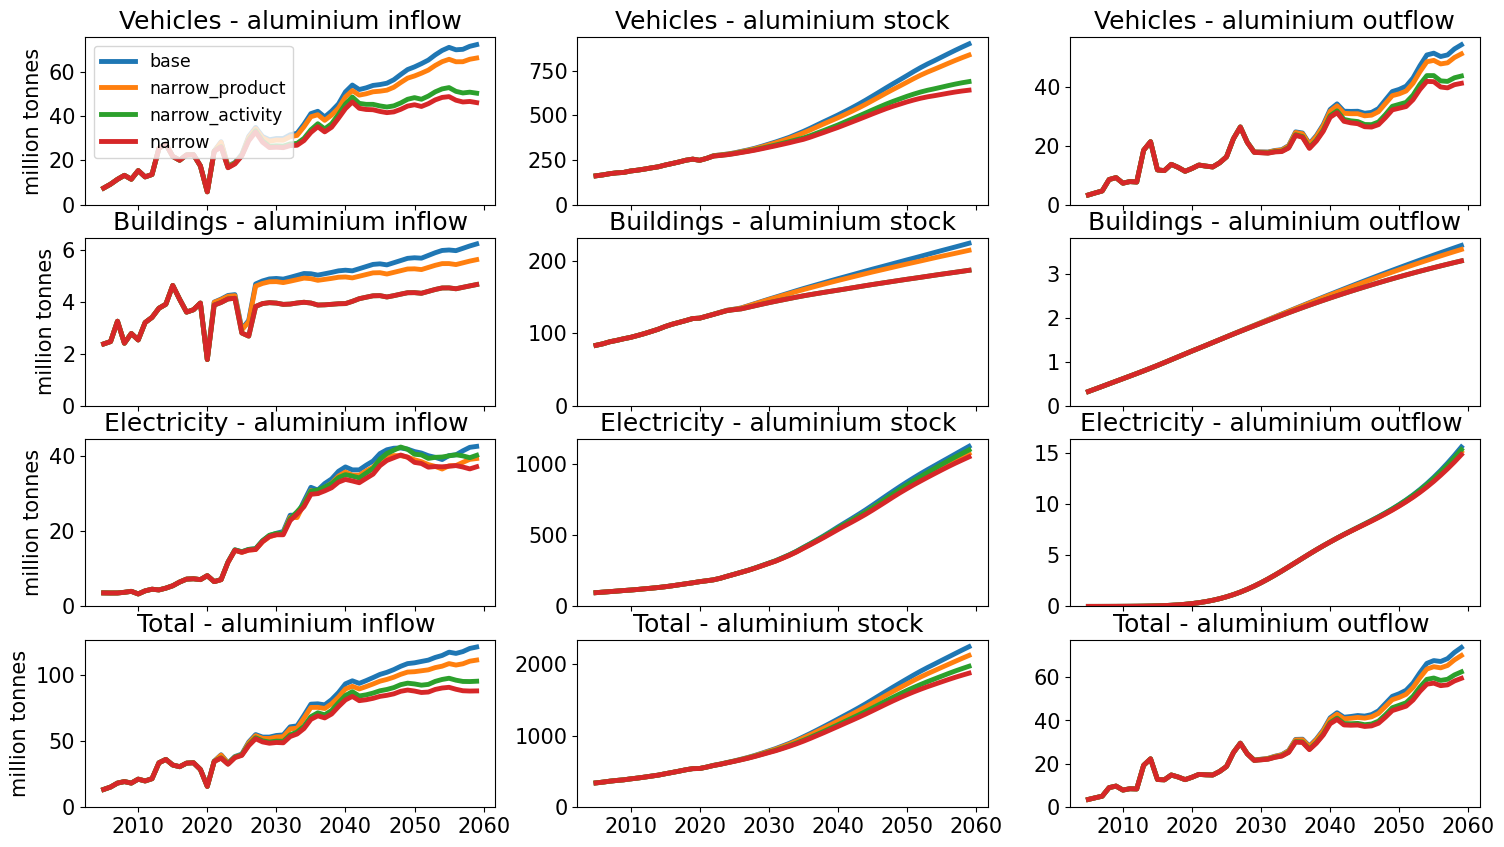

In [13]:
import seaborn as sns
region = "World" # "World" OR region code (e.g., "CHN", "BRA"...)
t0 = 2005
tf = 2060
linewidth = 3.5 
alpha=1
material = "aluminium"


fig, axes = plt.subplots(4, 3, figsize=(18, 10), sharex=True)
axes = axes.flatten()   # flatten 2D array of axes to 1D for easier indexing
colors = sns.color_palette("tab10")
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)


# --- Vehicles - steel inflow ---
for scen_id, output in all_output.items():
    inflow = output["inflow_materials"][0].to_array().sel(time=range(t0, tf))
    time = inflow.coords["time"]
    if region == "World":
        axes[0].plot(time, inflow.sel(material=material).sum("Type").sum("Region") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
    else:
        axes[0].plot(time, inflow.sel(material=material, Region = region ).sum("Type") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
axes[0].set_title(f"Vehicles - {material} inflow")
axes[0].set_ylabel("million tonnes")
axes[0].set_ylim(bottom=0)

# --- Vehicles - steel stock ---
for scen_id, output in all_output.items():
    stock = output["stock_by_cohort_materials"][0].sel(Time=range(t0, tf))
    Time = stock.coords["Time"]
    if region == "World":
        axes[1].plot(Time, stock.sel(material=material).sum("Type").sum("Region") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
    else:
        axes[1].plot(Time, stock.sel(material=material, Region = region ).sum("Type") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
axes[1].set_title(f"Vehicles - {material} stock")
axes[1].set_ylim(bottom=0)

# --- Vehicles - steel outflow ---
for scen_id, output in all_output.items():
    outflow = output["outflow_by_cohort_materials"][0].to_array().sel(time=range(t0, tf))
    time = outflow.coords["time"]
    if region == "World":
        axes[2].plot(time, outflow.sel(material=material).sum("Type").sum("Region") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
    else:
        axes[2].plot(time, outflow.sel(material=material, Region = region ).sum("Type") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
axes[2].set_title(f"Vehicles - {material} outflow")
axes[2].set_ylim(bottom=0)

# --- Buildings - steel inflow ---
for scen_id, output in all_output.items():
    inflow = output["inflow_materials"][1].to_array().sel(time=range(t0, tf))
    time = inflow.coords["time"]
    if region == "World":
        axes[3].plot(time, inflow.sel(material=material).sum("Type").sum("Region") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
    else:
        axes[3].plot(time, inflow.sel(material=material, Region = region ).sum("Type") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
axes[3].set_title(f"Buildings - {material} inflow")
axes[3].set_ylabel("million tonnes")
axes[3].set_ylim(bottom=0)

# --- Buildings - steel stock ---
for scen_id, output in all_output.items():
    stock = output["stock_by_cohort_materials"][1].sel(Time=range(t0, tf))
    Time = stock.coords["Time"]
    if region == "World":
        axes[4].plot(Time, stock.sel(material=material).sum("Type").sum("Region") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
    else:
        axes[4].plot(Time, stock.sel(material=material, Region = region ).sum("Type") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
axes[4].set_title(f"Buildings - {material} stock")
axes[4].set_ylim(bottom=0)

# --- Buildings - steel outflow ---
for scen_id, output in all_output.items():
    outflow = output["outflow_by_cohort_materials"][1].to_array().sel(time=range(t0, tf))
    time = outflow.coords["time"]
    if region == "World":
        axes[5].plot(time, outflow.sel(material=material).sum("Type").sum("Region") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
    else:
        axes[5].plot(time, outflow.sel(material=material, Region = region ).sum("Type") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
axes[5].set_title(f"Buildings - {material} outflow")
axes[5].set_ylim(bottom=0)

elec_idxs = [2, 3, 4, 5, 6]  # sectors elc_gen, elc_grid_lines, elc_grid_add, elc_stor_phs, elc_stor_other

# --- Electricity - steel inflow ---
for scen_id, output in all_output.items():
    if region == "World":
        inflows = [
                output["inflow_materials"][i].to_array().sel(time=range(t0, tf)).sum("Region")
                for i in elec_idxs
            ]
        inflow_elec = xr.concat(inflows, dim="subsector").sum("subsector")  # aggregate sectors 2–6
        time = inflow_elec.coords["time"]
    else:
        inflows = [
            output["inflow_materials"][i].to_array().sel(time=range(t0, tf), Region=region)
            for i in elec_idxs
        ]
        inflow_elec = xr.concat(inflows, dim="subsector").sum("subsector")  # aggregate sectors 2–6
        time = inflow_elec.coords["time"]

    axes[6].plot(
        time,
        inflow_elec.sel(material=material).sum("Type") / 1e9,
        label=scen_id,
        linewidth=linewidth,
        alpha=alpha,
    )
axes[6].set_title(f"Electricity - {material} inflow ")
axes[6].set_ylabel("million tonnes")
axes[6].set_ylim(bottom=0)

# --- Electricity - steel stock ---
for scen_id, output in all_output.items():
    if region == "World":
        stocks = [
            output["stock_by_cohort_materials"][i].sel(Time=range(t0, tf)).sum("Region")
            for i in elec_idxs
        ]
        stock_elec = xr.concat(stocks, dim="subsector").sum("subsector")
        Time = stock_elec.coords["Time"]
    else:
        stocks = [
            output["stock_by_cohort_materials"][i].sel(Time=range(t0, tf), Region=region)
            for i in elec_idxs
        ]
        stock_elec = xr.concat(stocks, dim="subsector").sum("subsector")
        Time = stock_elec.coords["Time"]

    axes[7].plot(
        Time,
        stock_elec.sel(material=material).sum("Type") / 1e9,
        label=scen_id,
        linewidth=linewidth,
        alpha=alpha,
    )
axes[7].set_title(f"Electricity - {material} stock ")
axes[7].set_ylim(bottom=0)


# --- Electricity - steel outflow ---
for scen_id, output in all_output.items():
    if region == "World":
        outflows = [
            output["outflow_by_cohort_materials"][i].to_array().sel(time=range(t0, tf)).sum("Region")
            for i in elec_idxs
        ]
        outflow_elec = xr.concat(outflows, dim="subsector").sum("subsector")
        time = outflow_elec.coords["time"]
    else:
        outflows = [
            output["outflow_by_cohort_materials"][i].to_array().sel(time=range(t0, tf), Region=region)
            for i in elec_idxs
        ]
        outflow_elec = xr.concat(outflows, dim="subsector").sum("subsector")
        time = outflow_elec.coords["time"]

    axes[8].plot(
        time,
        outflow_elec.sel(material=material).sum("Type") / 1e9,
        label=scen_id,
        linewidth=linewidth,
        alpha=alpha,
    )
axes[8].set_title(f"Electricity - {material} outflow ")
axes[8].set_ylim(bottom=0)


total_idxs = [0, 1, 2, 3, 4, 5, 6]

# --- Total - steel inflow  ---
for scen_id, output in all_output.items():
    if region == "World":
        inflows = [
            output["inflow_materials"][i].to_array().sel(time=range(t0, tf)).sum("Region")
            for i in total_idxs
        ]
        inflow_total = xr.concat(inflows, dim="subsector").sum("subsector")  
        time = inflow_total.coords["time"]
    else:
        inflows = [
            output["inflow_materials"][i].to_array().sel(time=range(t0, tf), Region=region)
            for i in total_idxs
        ]
        inflow_total = xr.concat(inflows, dim="subsector").sum("subsector")  
        time = inflow_total.coords["time"]
    axes[9].plot(
        time,
        inflow_total.sel(material=material).sum("Type") / 1e9,
        label=scen_id,
        linewidth=linewidth,
        alpha=alpha,
    )
axes[9].set_title(f"Total - {material} inflow ")
axes[9].set_ylabel("million tonnes")
axes[9].set_ylim(bottom=0)


# --- Total - steel stock ---
for scen_id, output in all_output.items():
    if region == "World":
        stocks = [
            output["stock_by_cohort_materials"][i].sel(Time=range(t0, tf)).sum("Region")
            for i in total_idxs
        ]
        stock_total = xr.concat(stocks, dim="subsector").sum("subsector")
        Time = stock_total.coords["Time"]
    else:   
        stocks = [
            output["stock_by_cohort_materials"][i].sel(Time=range(t0, tf), Region = region)
            for i in total_idxs
        ]
        stock_total = xr.concat(stocks, dim="subsector").sum("subsector")
        Time = stock_total.coords["Time"]
    axes[10].plot(
        Time,
        stock_total.sel(material=material).sum("Type") / 1e9,
        label=scen_id,
        linewidth=linewidth,
        alpha=alpha,
    )
axes[10].set_title(f"Total - {material} stock ")
axes[10].set_ylim(bottom=0)


# --- Total - steel outflow ---
for scen_id, output in all_output.items():
    if region == "World":
        outflows = [
            output["outflow_by_cohort_materials"][i].to_array().sel(time=range(t0, tf)).sum("Region")
            for i in total_idxs
        ]
        outflow_total = xr.concat(outflows, dim="subsector").sum("subsector")
        time = outflow_total.coords["time"]
    else:
        outflows = [
            output["outflow_by_cohort_materials"][i].to_array().sel(time=range(t0, tf), Region=region)
            for i in total_idxs
        ]
        outflow_total = xr.concat(outflows, dim="subsector").sum("subsector")
        time = outflow_total.coords["time"]

    axes[11].plot(
        time,
        outflow_total.sel(material=material).sum("Type") / 1e9,
        label=scen_id,
        linewidth=linewidth,
        alpha=alpha,
    )
axes[11].set_title(f"Total - {material} outflow ")

axes[11].set_ylim(bottom=0)


# Legend and layout
axes[0].legend(loc="upper left", fontsize='small')
plt.rcParams.update({'font.size': 15})


#plt.tight_layout()
plt.show()

In [34]:
material = "cement"
variable = "inflow_materials"
res_types = [ 'Appartment - Rural', 'Appartment - Urban', 'Detached - Rural',
       'Detached - Urban', 'High-rise - Rural', 'High-rise - Urban',
       'Semi-detached - Rural', 'Semi-detached - Urban']
# defining sectoral components 

rest_of = all_output["base"][variable][7].sel(material=material)*1000  # in kg

if material == "cement":
    buildings_commercial = all_output["base"][variable][1].to_array().sel(material=material).sum("Type") # commercial buildings only if cement
    buildings_residential = all_output["base"][variable][1].to_array().sel(material="concrete", Type = res_types).sum("Type")*0.12 # residential buildings only have concrete
    buildings = buildings_commercial + buildings_residential
    electricity_gen = all_output["base"][variable][2].to_array().sel(material="concrete").sum("Type")*0.12
    electricity_grid_lines = all_output["base"][variable][3].to_array().sel(material="concrete").sum("Type")*0.12
    electricity_grid_add = all_output["base"][variable][4].to_array().sel(material="concrete").sum("Type")*0.12
    electricity_stor = all_output["base"][variable][5].to_array().sel(material="concrete").sum("Type")*0.12
    electricity_stor_other = all_output["base"][variable][6].to_array().sel(material="concrete").sum("Type")*0.12
else: 
    vehicles = all_output["base"][variable][0].to_array().sel(material=material).sum("Type") # vehicles do not use cement
    buildings = all_output["base"][variable][1].to_array().sel(material=material).sum("Type")
    electricity_gen = all_output["base"][variable][2].to_array().sel(material=material).sum("Type")
    electricity_grid_lines = all_output["base"][variable][3].to_array().sel(material=material).sum("Type")
    electricity_grid_add = all_output["base"][variable][4].to_array().sel(material=material).sum("Type")
    electricity_stor = all_output["base"][variable][5].to_array().sel(material=material).sum("Type")
    electricity_stor_other = all_output["base"][variable][6].to_array().sel(material=material).sum("Type")

electricity = electricity_gen + electricity_grid_lines + electricity_grid_add + electricity_stor + electricity_stor_other

if material == "cement": 
    #  align time/region and fill missing with 0, then sum
    buildings, electricity, rest_of = xr.align(buildings, electricity, rest_of, join="outer", fill_value=0.0)
    total_inflow = buildings + electricity + rest_of
else:
    buildings, vehicles, electricity, rest_of = xr.align(buildings, vehicles, electricity, rest_of, join="outer", fill_value=0.0)
    total_inflow = buildings + vehicles + electricity + rest_of


# start at 1972
total_inflow = total_inflow.sel(time=slice(1980, None))


def plot_by_region(da, title, start_year=1980, ncols=6):

    # clip
    da = da.sel(time=slice(start_year, None))

    regions = da["Region"].values
    years = da["time"].values

    n = len(regions)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*2.2), sharex=True, sharey=False)
    axes = np.asarray(axes).ravel()

    for i, region in enumerate(regions):
        ax = axes[i]
        s = da.sel(Region=region)
        ax.plot(s["time"].values, s.values)
        ax.set_title(str(region), fontsize=9)
        ax.tick_params(labelsize=8)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(title, fontsize=12)
    fig.tight_layout(rect=[0, 0.02, 1, 0.95])
    plt.show()



In [30]:
import warnings
import pandas as pd
from pint.errors import UnitStrippedWarning
from pathlib import Path

warnings.filterwarnings("ignore", category=UnitStrippedWarning)

def sec_label(sec):
    return sec if isinstance(sec, str) else sec.name

output_dir = Path("..", "data", "output", "TIMER_input")
output_dir.mkdir(exist_ok=True)

common_vars = ["inflow_materials", "outflow_by_cohort_materials"]
rest_of_vars = ["inflow_materials"]
eol_vars = ["sum_outflow", "reusable_materials", "recyclable_materials"]

sector_unit_conversion = {
    "vehicles": {"factor": 1e-9, "unit": "Mt"},
    "buildings": {"factor": 1e-9, "unit": "Mt"},
    "rest_of": {"factor": 1e-6, "unit": "Mt"},  # rest_of is in tonnes
    "elc_gen": {"factor": 1e-9, "unit": "Mt"},
    "elc_grid_lines": {"factor": 1e-9, "unit": "Mt"},
    "elc_grid_add": {"factor": 1e-9, "unit": "Mt"},
    "elc_stor_phs": {"factor": 1e-9, "unit": "Mt"},
    "elc_stor_other": {"factor": 1e-9, "unit": "Mt"},
    "eol": {"factor": 1e-9, "unit": "Mt"},
}

# Make sure these are strings; your earlier code had bare names which will crash unless they are variables
sector_list = ["vehicles", "buildings", "elc_gen", "elc_grid_lines", "elc_grid_add", "elc_stor_phs", "elc_stor_other"]

# Residential building types
res_types = [
    "Appartment - Rural", "Appartment - Urban",
    "Detached - Rural", "Detached - Urban",
    "High-rise - Rural", "High-rise - Urban",
    "Semi-detached - Rural", "Semi-detached - Urban",
]
cement_in_concrete_ratio = 0.12  # cement share in concrete (your assumption)

all_rows = []

for scen_id, outputs in all_output.items():
    print(f"Processing {scen_id}")
    rows = []

    for mat in materials:

        # ----------------- vehicles, buildings and electricity sectors -----------------
        for var in common_vars:
            for i, sec in enumerate(sector_list):
                sec_name = sec_label(sec)
                conv = sector_unit_conversion[sec_name]

                # ---- totals across Type (subsector = Total) ----
                da_total = outputs[var][i].to_array()
                da_total = da_total.reindex(material=materials, fill_value=0).sel(material=mat)
                if "Type" in da_total.dims:
                    da_total = da_total.sum(dim="Type")

                df_total = da_total.to_dataframe(name="value").reset_index()
                df_total["value"] = df_total["value"] * conv["factor"]
                df_total["unit"] = conv["unit"]
                df_total["material"] = mat
                df_total["sector"] = sec_name
                df_total["variable"] = var
                df_total["scenario"] = scen_id
                df_total["subsector"] = "Total"
                rows.append(df_total)

                # ---- per-Type values (subsector = Type) ----
                da_by_type = outputs[var][i].to_array()
                da_by_type = da_by_type.reindex(material=materials, fill_value=0).sel(material=mat)

                if "Type" in da_by_type.dims:
                    df_by_type = da_by_type.to_dataframe(name="value").reset_index()
                    df_by_type["value"] = df_by_type["value"] * conv["factor"]
                    df_by_type["unit"] = conv["unit"]
                    df_by_type["material"] = mat
                    df_by_type["sector"] = sec_name
                    df_by_type["variable"] = var
                    df_by_type["scenario"] = scen_id
                    df_by_type["subsector"] = df_by_type["Type"].astype(str)
                    df_by_type = df_by_type.drop(columns=["Type"])
                    rows.append(df_by_type)

        # ----------------- rest-of sector -----------------
        for var in rest_of_vars:
            da = outputs[var][7]  # your indexing convention

            if "Time" in da.dims:
                da = da.rename({"Time": "time"})

            da = da.reindex(material=materials, fill_value=0).sel(material=mat)
            df = da.to_dataframe(name="value").reset_index()

            conv = sector_unit_conversion["rest_of"]
            df["value"] = df["value"] * conv["factor"]
            df["unit"] = conv["unit"]
            df["material"] = mat
            df["sector"] = "rest_of"
            df["variable"] = var
            df["scenario"] = scen_id
            df["subsector"] = "Total"
            rows.append(df)

        # ----------------- eol sector -----------------
        for var in eol_vars:
            # totals across Type
            da_total = outputs[var].to_array()
            da_total = da_total.reindex(material=materials, fill_value=0).sel(material=mat).sum(dim="Type")
            df_total = da_total.to_dataframe(name="value").reset_index()

            df_total["value"] = df_total["value"] * sector_unit_conversion["eol"]["factor"]
            df_total["unit"] = sector_unit_conversion["eol"]["unit"]
            df_total["material"] = mat
            df_total["sector"] = "eol"
            df_total["variable"] = var
            df_total["scenario"] = scen_id
            df_total["subsector"] = "Total"
            rows.append(df_total)

            # per-Type (subsector = Type)
            da_by_type = outputs[var].to_array().sel(material=mat)
            df_by_type = da_by_type.to_dataframe(name="value").reset_index()

            df_by_type["value"] = df_by_type["value"] * sector_unit_conversion["eol"]["factor"]
            df_by_type["unit"] = sector_unit_conversion["eol"]["unit"]
            df_by_type["material"] = mat
            df_by_type["sector"] = "eol"
            df_by_type["variable"] = var
            df_by_type["scenario"] = scen_id
            df_by_type["subsector"] = df_by_type["Type"].astype(str)
            df_by_type = df_by_type.drop(columns=["Type"])
            rows.append(df_by_type)

        # ----------------- image_input aggregates -----------------
        df_rows = pd.concat(rows, ignore_index=True)
        key_cols = ["scenario", "Region", "material", "time"]

        # (A) Base inflow totals (exclude rest_of from common, then add rest_of once)
        inflow_common = df_rows[
            (df_rows["scenario"] == scen_id) &
            (df_rows["material"] == mat) &
            (df_rows["variable"] == "inflow_materials") &
            (df_rows["subsector"] == "Total") &
            (df_rows["sector"] != "rest_of")
        ][key_cols + ["value"]].copy()

        inflow_rest = df_rows[
            (df_rows["scenario"] == scen_id) &
            (df_rows["material"] == mat) &
            (df_rows["variable"] == "inflow_materials") &
            (df_rows["sector"] == "rest_of") &
            (df_rows["subsector"] == "Total")
        ][key_cols + ["value"]].copy()

        total_inflows = (
            pd.concat([inflow_common, inflow_rest], ignore_index=True)
              .groupby(key_cols, as_index=False)["value"].sum()
        )

        # (B) Add cement-from-residential-concrete and from electricity-concrete ONLY when mat == cement
        if mat == "cement":
            cement_from_conc = df_rows[
                (df_rows["scenario"] == scen_id) &
                (df_rows["variable"] == "inflow_materials") &
                (df_rows["sector"] == "buildings") &
                (df_rows["material"] == "concrete") &
                (df_rows["subsector"].isin(res_types))
            ][["scenario", "Region", "time", "value"]].copy()

            cement_from_conc_elc = df_rows[
                (df_rows["scenario"] == scen_id) &
                (df_rows["variable"] == "inflow_materials") &
                (df_rows["sector"] == "electricity") &
                (df_rows["material"] == "concrete") &
                (df_rows["subsector"] == "Total")
            ][["scenario", "Region", "time", "value"]].copy()

            cement_from_conc = pd.concat([cement_from_conc, cement_from_conc_elc], ignore_index=True)

            if not cement_from_conc.empty:
                cement_from_conc["value"] = cement_from_conc["value"] * cement_in_concrete_ratio
            
                # bring to same key_cols grain
                cement_from_conc = cement_from_conc.groupby(["scenario", "Region", "time"], as_index=False)["value"].sum()
                cement_from_conc["material"] = "cement"

                # add into total inflows
                total_inflows = (
                    pd.concat([total_inflows, cement_from_conc[key_cols + ["value"]]], ignore_index=True)
                      .groupby(key_cols, as_index=False)["value"].sum()
                )

                # Optional audit line
                audit = cement_from_conc.copy()
                audit["unit"] = "Mt"
                audit["sector"] = "image_input"
                audit["subsector"] = "Total"
                audit["variable"] = "InflowCementFromConcreteResidential"
                rows.append(audit[key_cols + ["value", "unit", "sector", "subsector", "variable"]])

        # Write TotalInflow
        total_inflows_out = total_inflows.copy()
        total_inflows_out["unit"] = "Mt"
        total_inflows_out["sector"] = "image_input"
        total_inflows_out["subsector"] = "Total"
        total_inflows_out["variable"] = "TotalInflow"
        rows.append(total_inflows_out)

        # TotalReusable (from eol totals)
        total_reusables = df_rows[
            (df_rows["scenario"] == scen_id) &
            (df_rows["material"] == mat) &
            (df_rows["variable"] == "reusable_materials") &
            (df_rows["sector"] == "eol") &
            (df_rows["subsector"] == "Total")
        ][key_cols + ["value"]].copy()

        total_reusables = total_reusables.groupby(key_cols, as_index=False)["value"].sum()

        total_reusables_out = total_reusables.copy()
        total_reusables_out["unit"] = "Mt"
        total_reusables_out["sector"] = "image_input"
        total_reusables_out["subsector"] = "Total"
        total_reusables_out["variable"] = "TotalReusable"
        rows.append(total_reusables_out)

        # ExoDemand = TotalInflow - TotalReusable
        exo = total_inflows.merge(
            total_reusables,
            on=key_cols,
            how="left",
            suffixes=("_in", "_re")
        )
        exo["value_re"] = exo["value_re"].fillna(0.0)
        exo["value"] = exo["value_in"] - exo["value_re"]
        exo["value"] = exo["value"].clip(lower=0)

        exo_out = exo[key_cols + ["value"]].copy()
        exo_out["unit"] = "Mt"
        exo_out["sector"] = "image_input"
        exo_out["subsector"] = "Total"
        exo_out["variable"] = "ExoDemand"
        rows.append(exo_out)

    all_rows.extend(rows)
    print(f"Finished {scen_id}")

# Combine all rows into a single DataFrame and pivot it
full_df = pd.concat(all_rows, ignore_index=True)

pivot_df = full_df.pivot_table(
    index=["scenario", "Region", "material", "variable", "unit", "sector", "subsector"],
    columns="time",
    values="value",
    aggfunc="sum"  # explicit, avoids silent averaging if duplicates exist
).reset_index()

pivot_df.to_csv(output_dir / "IMAGE_materials_to_TIMER_19jan26.csv", index=False)


Processing base


KeyboardInterrupt: 